# CSoT'26 - ML in Astronomy - Week 3 . Part 1: A CNN and the Training Loop (Starter)

**Goal:** Replace the Week-2 MLP with a **Convolutional Neural Network**, then write the **training loop** that teaches it. By the end you'll watch the training loss fall over several epochs.

**Before you begin:**
1. Switch this notebook to a **GPU runtime** (`Runtime -> Change runtime type -> GPU`). This week it actually matters for speed.
2. Read [`01-convolutions-and-pooling.md`](../01-convolutions-and-pooling.md), [`02-building-a-cnn.md`](../02-building-a-cnn.md), and [`03-the-training-loop.md`](../03-the-training-loop.md).

Replace each `TODO` with working code. **Do not** open the solution until you've genuinely attempted every TODO.

## Step 0 - Re-create the Week 1 data pipeline

Week 3 builds directly on the `DataLoader`s from Week 1. Paste that pipeline below (download is commented out in the Week-1 solution - uncomment it the first time). If you saved `galaxy_data/` to Google Drive in Week 1, re-mount Drive and point `ImageFolder` at it instead of re-downloading.

After this section you should have `train_loader`, `val_loader`, `test_loader`, `train_ds`, and `num_classes`.

In [8]:
import math
import random
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


In [9]:

import json

KAGGLE_USERNAME = "mandiraaich"
KAGGLE_KEY = "KGAT_da75e819847ce5948097dd89b3146c55"

kaggle_creds = {
    "username": KAGGLE_USERNAME,
    "key": KAGGLE_KEY
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_creds, f)

print("kaggle.json created successfully!")
!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets list -s galaxy-zoo | head

!kaggle datasets download \
    -d jaimetrickz/galaxy-zoo-2-images \
    --path /content/

print("Download complete.")
# Unzip the images
import zipfile

ZIP_PATH = "/content/galaxy-zoo-2-images.zip"
EXTRACT_TO = "/content/galaxy_raw"

if not os.path.exists(EXTRACT_TO):
    print("Extracting... (this may take a few minutes)")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_TO)
    print("Extraction complete.")
else:
    print("Already extracted.")

# Peek at the directory structure
for root, dirs, files_in_dir in os.walk(EXTRACT_TO):
    level = root.replace(EXTRACT_TO, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 1:
        sub_indent = '  ' * (level + 1)
        for f in files_in_dir[:5]:
            print(f"{sub_indent}{f}")
        if len(files_in_dir) > 5:
            print(f"{sub_indent}... and {len(files_in_dir)-5} more files")
    break  # only top level


kaggle.json created successfully!
ref                                       title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------  ---------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
jaimetrickz/galaxy-zoo-2-images           Galaxy Zoo 2: Images                           3281862708  2021-01-26 16:25:27.667000          10088         34  0.9411765        
robertmifsud/resized-reduced-gz2-images   Resized and Reduced Galaxy Zoo 2 Images        1934213890  2023-05-25 23:12:04.167000            700          6  0.8235294        
anjosut/galaxy-zoo-classification         Galaxy Zoo classification                       397550426  2023-04-08 04:28:53.070000            640          3  0.3529412        
zhuangjw/galaxy-zoo-cleaned               galaxy_zoo_cleaned                             2352353415  

In [10]:
# Download the Hart et al. 2016 morphology catalogue
import os

LABELS_URL = "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz"
LABELS_PATH = "/content/galaxy_raw/gz2_hart16.csv.gz"

if not os.path.exists(LABELS_PATH.replace(".gz", "")):
    !wget --no-check-certificate \
        "{LABELS_URL}" \
        -O "{LABELS_PATH}"

    !gunzip -f "{LABELS_PATH}"
    print("Labels downloaded.")
else:
    print("Labels already present.")

LABELS_PATH = LABELS_PATH.replace(".gz", "")
from pathlib import Path

RAW_ROOT = Path("/content/galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2" / "images"
DATA_ROOT = Path("/content/galaxy_data")
LABELS_URL = "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz"

print("RAW_ROOT =", RAW_ROOT)
print("IMAGES_DIR =", IMAGES_DIR)
print("DATA_ROOT =", DATA_ROOT)
print("RAW_ROOT contents:", sorted(p.name for p in RAW_ROOT.iterdir()))
jpg_count = sum(1 for _ in IMAGES_DIR.glob("*.jpg"))
print(f"Flat JPG count in {IMAGES_DIR}: {jpg_count:,}")
import pandas as pd
mapping_head = pd.read_csv(RAW_ROOT / "gz2_filename_mapping.csv", nrows=3)
print(mapping_head)


--2026-06-25 17:38:38--  https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz
Resolving gz2hart.s3.amazonaws.com (gz2hart.s3.amazonaws.com)... 16.15.223.74, 16.15.252.112, 52.217.75.20, ...
Connecting to gz2hart.s3.amazonaws.com (gz2hart.s3.amazonaws.com)|16.15.223.74|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 78513011 (75M) [application/x-gzip]
Saving to: ‘/content/galaxy_raw/gz2_hart16.csv.gz’

/content/galaxy_raw 100%[===================>]  74.88M  34.6MB/s    in 2.2s    

2026-06-25 17:38:41 (34.6 MB/s) - ‘/content/galaxy_raw/gz2_hart16.csv.gz’ saved [78513011/78513011]

Labels downloaded.
RAW_ROOT = /content/galaxy_raw
IMAGES_DIR = /content/galaxy_raw/images_gz2/images
DATA_ROOT = /content/galaxy_data
RAW_ROOT contents: ['gz2_filename_mapping.csv', 'gz2_hart16.csv', 'images_gz2']
Flat JPG count in /content/galaxy_raw/images_gz2/images: 243,434
                objid    sample  asset_id
0  587722981736120347  original         1
1  587722981736579107  ori

In [11]:
!rm -f /content/galaxy_raw/gz2_hart16.csv
!rm -f /content/galaxy_raw/gz2_hart16.csv.gz

In [12]:
!wget --no-check-certificate \
https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz \
-O /content/galaxy_raw/gz2_hart16.csv.gz

--2026-06-25 17:38:48--  https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz
Resolving gz2hart.s3.amazonaws.com (gz2hart.s3.amazonaws.com)... 16.15.207.42, 16.15.199.231, 54.231.199.241, ...
Connecting to gz2hart.s3.amazonaws.com (gz2hart.s3.amazonaws.com)|16.15.207.42|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 78513011 (75M) [application/x-gzip]
Saving to: ‘/content/galaxy_raw/gz2_hart16.csv.gz’

/content/galaxy_raw 100%[===================>]  74.88M  27.8MB/s    in 2.7s    

2026-06-25 17:38:51 (27.8 MB/s) - ‘/content/galaxy_raw/gz2_hart16.csv.gz’ saved [78513011/78513011]



In [13]:
!gunzip -f /content/galaxy_raw/gz2_hart16.csv.gz

In [14]:
import pandas as pd

df = pd.read_csv("/content/galaxy_raw/gz2_hart16.csv")
print(df.head())
print(df.shape)

             dr7objid          ra        dec     rastring    decstring  \
0  587732591714893851  179.042984  60.522518  11:56:10.32  +60:31:21.1   
1  588009368545984617  135.084396  52.494240  09:00:20.26  +52:29:39.3   
2  587732484359913515  183.371979  50.741508  12:13:29.27  +50:44:29.4   
3  587741723357282317  186.251953  28.558598  12:25:00.47  +28:33:31.0   
4  587738410866966577  161.086395  14.084465  10:44:20.73  +14:05:04.1   

     sample gz2_class  total_classifications  total_votes  \
0  original      Sc+t                     45          342   
1  original      Sb+t                     42          332   
2  original        Ei                     36          125   
3  original      Sc+t                     28          218   
4  original        Er                     43          151   

   t01_smooth_or_features_a01_smooth_count  ...  \
0                                        0  ...   
1                                        1  ...   
2                                  

In [15]:

def build_imagefolder_layout(
    images_dir,
    mapping_csv,
    labels_csv,
    out_root,
    per_class=200,
    seed=42,
):

    df = pd.read_csv(mapping_csv).merge((
        pd.read_csv(labels_csv)
        .rename(columns={"dr7objid": "objid"})
    )[["objid", "gz2_class"]],
        on="objid",
        how="inner"
    )

    def high_level_label(gz2_class):
        if not gz2_class or gz2_class == "A":
            return None

        if gz2_class.startswith("E"):
            return "Elliptical"

        if gz2_class.startswith("SB"):
            return "Spiral_barred"

        if gz2_class.startswith("S"):
            return "Spiral"

        return None

    df["label"] = df["gz2_class"].map(high_level_label)
    df = df.dropna(subset=["label"])

    images_dir = Path(images_dir)
    out_root = Path(out_root)

    out_root.mkdir(parents=True, exist_ok=True)

    counts = {}

    for label in sorted(df["label"].unique()):

        class_dir = out_root / label
        class_dir.mkdir(exist_ok=True)

        rows = df[df["label"] == label]

        rows = rows[
            rows["asset_id"].apply(
                lambda x: (images_dir / f"{int(x)}.jpg").exists()
            )
        ]

        if len(rows) > per_class:
            rows = rows.sample(
                n=per_class,
                random_state=seed
            )

        linked = 0

        for _, row in rows.iterrows():

            src = images_dir / f"{int(row.asset_id)}.jpg"
            dst = class_dir / f"{int(row.asset_id)}.jpg"

            if not dst.exists():
                os.symlink(src.resolve(), dst)

            linked += 1

        counts[label] = linked

    return counts
counts = build_imagefolder_layout(
        IMAGES_DIR,
        RAW_ROOT / "gz2_filename_mapping.csv",
        RAW_ROOT / "gz2_hart16.csv",
        DATA_ROOT,
        per_class=200,
    )

print(counts)
import pandas as pd

pd.read_csv("/content/galaxy_raw/gz2_hart16.csv").head()
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3)
])
from torchvision.datasets import ImageFolder

dataset = ImageFolder(
    root=DATA_ROOT,
    transform=transform
)

print("Dataset size:", len(dataset))
print("Classes:", dataset.classes)
print("Class to index:", dataset.class_to_idx)
image, label = dataset[0]

print(image.shape)
print(image.dtype)
print(label)
print(dataset.classes[label])
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

images, labels = next(iter(loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

print("Labels:")
print(labels)
from torch.utils.data import random_split, DataLoader

# 80% train, 20% test
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print(len(train_dataset))
print(len(test_dataset))


{'Elliptical': 200, 'Spiral': 200, 'Spiral_barred': 200}
Dataset size: 600
Classes: ['Elliptical', 'Spiral', 'Spiral_barred']
Class to index: {'Elliptical': 0, 'Spiral': 1, 'Spiral_barred': 2}
torch.Size([3, 64, 64])
torch.float32
0
Elliptical
Images shape: torch.Size([32, 3, 64, 64])
Labels shape: torch.Size([32])
Labels:
tensor([0, 2, 2, 1, 2, 1, 1, 0, 0, 0, 2, 2, 1, 2, 2, 1, 0, 0, 0, 2, 2, 0, 0, 2,
        2, 2, 0, 0, 1, 1, 0, 1])
480
120


## Step 1 - Define the CNN

Two `Conv -> ReLU -> Pool` blocks (channels `3 -> 16 -> 32`, each conv `kernel_size=3, padding=1`), then a `Flatten -> Linear -> ReLU -> Linear` head. With a 64x64 input and two 2x2 pools, the feature maps are `(B, 32, 16, 16)`, so the flattened size is `32*16*16 = 8192`. The final layer returns **raw logits** (no softmax). Don't forget `super().__init__()`.

In [21]:
import torch
import torch.nn as nn
num_classes = len(dataset.classes)
class GalaxyCNN(nn.Module):

  def __init__(self, num_classes):
    super().__init__()

    self.features= nn.Sequential(
        nn.Conv2d(3,16,kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(16,32,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)

    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(8192,128),
        nn.ReLU(),
        nn.Linear(128,num_classes)
    )
  def forward(self,x):
    x = self.features(x)
    x = self.classifier(x)
    return x

## Step 2 - Instantiate and move to the device

Use the real `num_classes` from your data, and `.to(device)` so the model lives where the batches will.

In [22]:
model = GalaxyCNN(num_classes=num_classes).to(device)
print(model)

GalaxyCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)


## Step 3 - Forward-pass one real batch and count parameters

Pull a batch from `train_loader`, move it to the device, and confirm the output is `(batch_size, num_classes)`. Then print the parameter count - notice the convolutions are tiny and the first `Linear` dominates (compare with the Week-2 MLP's ~1.57M first layer).

In [24]:
images , labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)
logits = model(images)
print(logits.shape)
total = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total:,}")


torch.Size([32, 3])
Total parameters: 1,054,179


## Step 4 - Loss, optimiser, and a starting-loss sanity check

`CrossEntropyLoss` consumes raw logits + integer labels. `Adam` with `lr=1e-3` is the sensible default. An untrained model on `C` balanced classes should give a loss near `ln(C)`.

In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss = criterion(logits, labels)

print(loss.item(), "vs ln(C) =", math.log(num_classes))

1.1018242835998535 vs ln(C) = 1.0986122886681098


## Step 5 - The training loop

For each epoch, loop over `train_loader` and run the **five steps** every batch: `zero_grad -> forward -> loss -> backward -> step`. Accumulate a running loss and store the epoch average in `train_losses`. Call `model.train()` at the start of each epoch and `.to(device)` every batch.

In [29]:
num_epochs = 8
train_losses = []
for epoch in range(num_epochs):
    model.train(); running = 0.0
    for inputs, targets in train_loader:
      inputs, targets = inputs.to(device), targets.to(device)
      optimizer.zero_grad()
      outputs = model(inputs)
      loss = criterion(outputs, targets)
      loss.backward()
      optimizer.step()
      running += loss.item() * inputs.size(0)
    epoch_loss = running / len(train_loader.dataset)
    train_losses.append(epoch_loss)
print(f"Epoch {epoch+1:2d}/{num_epochs}  train loss: {epoch_loss:.4f}")

Epoch  8/8  train loss: 0.9883


## Step 6 - Plot the loss curve

A healthy run shows `train_losses` trending **down**. Small wiggles are fine; the trend is what matters.

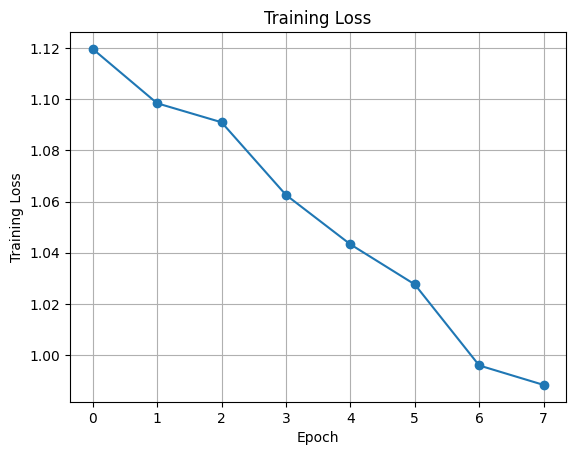

In [30]:
import matplotlib.pyplot as plt

plt.plot(train_losses, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss")

plt.grid(True)

plt.show()

## Step 7 (stretch) - Save Part 1's weights for Part 2

Optional but handy: save the trained weights so the Part-2 notebook can load them instead of re-training. Save to Drive so they survive a runtime recycle. (Saving/loading is covered fully in [`07-saving-and-loading-models.md`](../07-saving-and-loading-models.md).)

In [31]:
torch.save(model.state_dict(), "galaxy_model.pth")
print("Model saved successfully!")

Model saved successfully!


## Reflection *(write 2-3 sentences each)*

1. Your CNN's parameter count - where do most of the weights live, and why is that different from the Week-2 MLP?
2. Describe the shape of your training-loss curve. What would it mean if the loss never fell? If it went to `nan`?
3. Low training loss is necessary but not sufficient. What does Part 2 add to check the model is actually good?

*(Replace this prompt with your answers.)*